# Experiment: Hyperparameter Sweep

Three focused sweeps using `sweep()`. Features are built **once per section** and reused across all configs in that section.

| Section | Model | Parameter swept |
|---|---|---|
| 1 | Logistic Regression | `C` (regularisation strength) |
| 2 | Random Forest | `max_depth` |
| 3 | MLP | `hidden_dims` + `dropout` |

In [1]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    if not os.path.exists(REPO):
        os.system(f'git clone <your-repo-url>')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline import sweep

sns.set_theme(style='whitegrid')

BASE = {
    'wandb_project': 'applied-ai-coursework',
    'featurizer':    'full',
    'split_ratio':   0.8,
}

def results_df(param_grid, results, param_col, param_vals):
    """Build a tidy DataFrame from sweep output."""
    rows = []
    for val, r in zip(param_vals, results):
        m = r.metrics
        rows.append({
            param_col:     val,
            'ROC-AUC':     round(m['roc_auc'], 4),
            'F1':          round(m['f1'], 4),
            'Recall':      round(m['recall'], 4),
            'Recall(pos)': round(m['recall_pos'], 4),
            'Precision':   round(m['precision'], 4),
            'Time(s)':     round(r.elapsed_s, 1),
        })
    return pd.DataFrame(rows).set_index(param_col)


def plot_sweep(df, param_col, title):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, metric in zip(axes, ['ROC-AUC', 'F1', 'Recall', 'Recall(pos)']):
        ax.plot(df.index.astype(str), df[metric], marker='o', linewidth=2)
        ax.set_title(metric)
        ax.set_xlabel(param_col)
        ax.tick_params(axis='x', rotation=30)
        sns.despine(ax=ax)
    fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


---
## 1. Logistic Regression — Regularisation (`C`)

Small `C` = strong L2 regularisation (high bias, low variance).  
Large `C` = weak regularisation (low bias, higher variance).

In [3]:
LR_C_VALUES = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

lr_grid = [
    {
        'name':         f'lr_C{c}',
        'model':        'logistic_regression',
        'model_params': {'C': c, 'max_iter': 1000, 'class_weight': 'balanced'},
    }
    for c in LR_C_VALUES
]

lr_results = sweep(BASE, lr_grid)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\byamb\_netrc.



[sweep] featurizer=full  subsample=None  (9 configs)
  -> lr_C0.001


wandb: Currently logged in as: byambaa-bayarmandakh-25 (byambaa-bayarmandakh-25-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.65989
val_log_loss,0.67351


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-42-47_8632f9_lr_C0.001
  ROC-AUC=0.6143  F1=0.1670  Recall=0.5812  Recall(pos)=0.3979  (14.2s)
  -> lr_C0.01


...

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.65383
val_log_loss,0.66908


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-44-29_a76789_lr_C50.0
  ROC-AUC=0.6191  F1=0.1711  Recall=0.5799  Recall(pos)=0.3561  (14.6s)
  -> lr_C100.0


e:\UCL-Workspaces\applied-ai-coursework\.conda\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.65375
val_log_loss,0.66888


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-44-43_59665e_lr_C100.0
  ROC-AUC=0.6189  F1=0.1708  Recall=0.5802  Recall(pos)=0.3604  (14.1s)


,ROC-AUC,F1,Recall,Recall(<30),Precision,Time(s)
C,,,,,,
0.001,0.6143,0.1670,0.5812,0.3979,0.1057,14.2
0.010,0.6203,0.1703,0.5795,0.3583,0.1117,14.6
0.100,0.6193,0.1719,0.5819,0.3658,0.1124,13.5
0.500,0.6192,0.1706,0.5813,0.3711,0.1107,14.5
1.000,0.6192,0.1717,0.5812,0.3615,0.1126,15.2
5.000,0.6189,0.1708,0.5800,0.3583,0.1122,15.1
10.000,0.6189,0.1701,0.5787,0.3529,0.1121,14.4
50.000,0.6191,0.1711,0.5799,0.3561,0.1126,14.6
100.000,0.6189,0.1708,0.5802,0.3604,0.1119,14.1


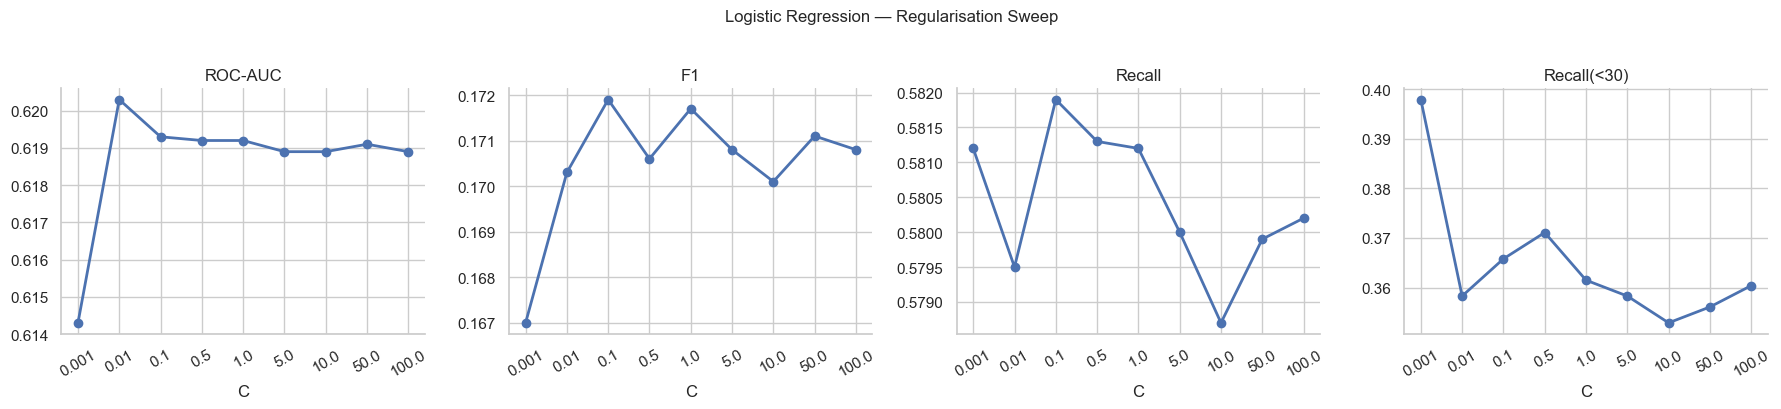

In [4]:
lr_df = results_df(lr_grid, lr_results, 'C', LR_C_VALUES)
display(lr_df)
plot_sweep(lr_df, 'C', 'Logistic Regression — Regularisation Sweep')

---
## 2. Random Forest — Tree Depth (`max_depth`)

Shallow trees = high bias. Deep/unconstrained trees = high variance.

In [5]:
RF_DEPTHS = [2, 4, 6, 8, 10, 15, 20, None]   # None = unconstrained

rf_grid = [
    {
        'name':         f'rf_depth{d}',
        'model':        'random_forest',
        'model_params': {
            'n_estimators':  200,
            'max_depth':     d,
            'class_weight':  'balanced',
            'n_jobs':        -1,
            'random_state':  42,
        },
    }
    for d in RF_DEPTHS
]

rf_results = sweep(BASE, rf_grid)


[sweep] featurizer=full  subsample=None  (8 configs)
  -> rf_depth2


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.67615
val_log_loss,0.67964


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-45-00_57f3b8_rf_depth2
  ROC-AUC=0.6148  F1=0.1685  Recall=0.5784  Recall(pos)=0.3626  (3.9s)
  -> rf_depth4


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.66372
val_log_loss,0.67076


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-45-04_a136c2_rf_depth4
  ROC-AUC=0.6187  F1=0.1711  Recall=0.5834  Recall(pos)=0.3840  (3.6s)
  -> rf_depth6


...

Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-45-21_64e2e1_rf_depth15
  ROC-AUC=0.6195  F1=0.1656  Recall=0.5857  Recall(pos)=0.4503  (5.4s)
  -> rf_depth20


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.31232
val_log_loss,0.40524


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-45-27_0989f6_rf_depth20
  ROC-AUC=0.6084  F1=0.1556  Recall=0.5691  Recall(pos)=0.3989  (5.9s)
  -> rf_depthNone


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.06792
val_log_loss,0.24321


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-45-33_c0802a_rf_depthNone
  ROC-AUC=0.6143  F1=0.1688  Recall=0.5738  Recall(pos)=0.3219  (7.7s)


,ROC-AUC,F1,Recall,Recall(<30),Precision,Time(s)
max_depth,,,,,,
2,0.6148,0.1685,0.5784,0.3626,0.1097,3.9
4,0.6187,0.1711,0.5834,0.3840,0.1101,3.6
6,0.6237,0.1727,0.5884,0.4107,0.1093,4.2
8,0.6264,0.1729,0.5831,0.3690,0.1129,4.1
10,0.6296,0.1729,0.5888,0.4128,0.1093,4.7
15,0.6195,0.1656,0.5857,0.4503,0.1015,5.4
20,0.6084,0.1556,0.5691,0.3989,0.0967,5.9
None,0.6143,0.1688,0.5738,0.3219,0.1144,7.7


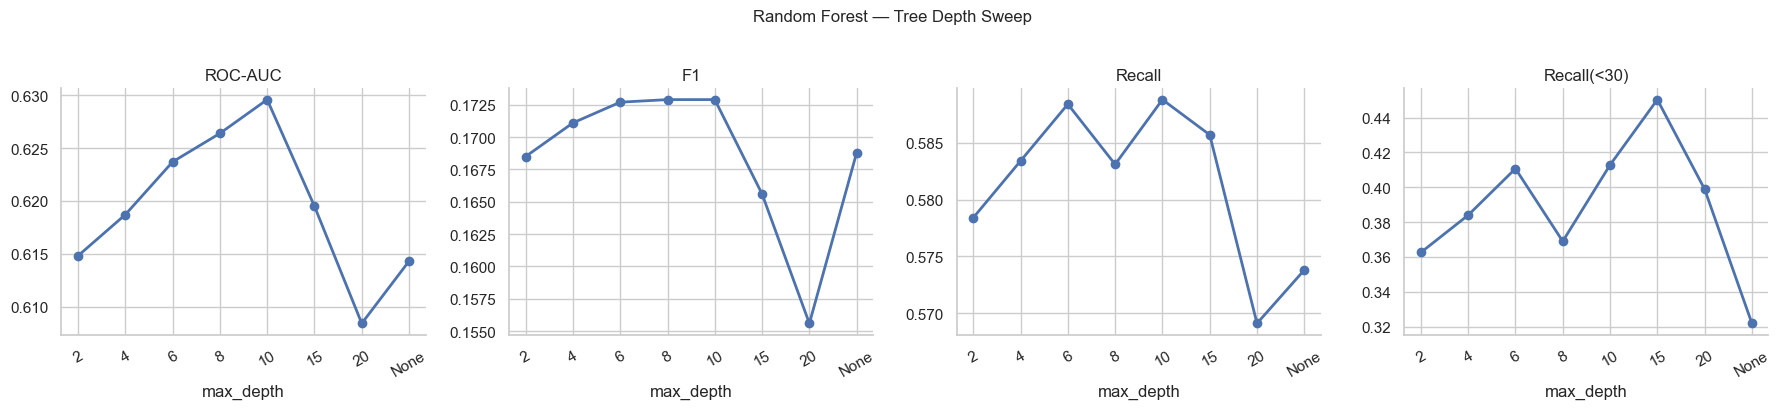

In [6]:
depth_labels = [str(d) if d is not None else 'None' for d in RF_DEPTHS]
rf_df = results_df(rf_grid, rf_results, 'max_depth', depth_labels)
display(rf_df)
plot_sweep(rf_df, 'max_depth', 'Random Forest — Tree Depth Sweep')

---
## 3. MLP — Architecture & Dropout

Joint sweep over hidden layer width and dropout rate. Each config is a different capacity/regularisation point.

In [7]:
MLP_CONFIGS = [
    {'hidden_dims': [64],           'dropout': 0.0},
    {'hidden_dims': [128, 64],      'dropout': 0.0},
    {'hidden_dims': [128, 64],      'dropout': 0.3},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.0},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.3},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.5},
    {'hidden_dims': [512, 256, 128],'dropout': 0.3},
]

mlp_grid = [
    {
        'name':        f'mlp_{"x".join(str(h) for h in c["hidden_dims"])}_d{int(c["dropout"]*10)}',
        'model':       'mlp',
        'hidden_dims': c['hidden_dims'],
        'dropout':     c['dropout'],
        'lr':          1e-3,
        'epochs':      80,
        'patience':    10,
        'batch_size':  256,
    }
    for c in MLP_CONFIGS
]

mlp_results = sweep(BASE, mlp_grid)


[sweep] featurizer=full  subsample=None  (7 configs)
  -> mlp_64_d0


Early stopping at epoch 28  (best val_loss 0.235367)


train_loss,█▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▆▂▂▃▂█▃▃▆▃▄▃▁▂▃▂▆▁▁▁▃▂▂▁▂▂▁▁
train_loss,0.29124
val_loss,0.23561


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-45-44_26e2cb_mlp_64_d0
  ROC-AUC=0.6260  F1=0.1709  Recall=0.5761  Recall(pos)=0.3273  (35.9s)
  -> mlp_128x64_d0


Early stopping at epoch 27  (best val_loss 0.236060)


...

train_loss,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▂▆▄▆▂▂▂▂▂▂▃▁▂▁▃▂▁▁▂▂▁▂
train_loss,0.29917
val_loss,0.2408


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-48-26_859461_mlp_256x128x64_d5
  ROC-AUC=0.6254  F1=0.1722  Recall=0.5731  Recall(pos)=0.2963  (40.6s)
  -> mlp_512x256x128_d3


Early stopping at epoch 25  (best val_loss 0.235407)


train_loss,█▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_loss,▅▄█▆▅▃█▃▁▅▄▂▂▂▁▄▃▄▂▄▃▄▃▃▅
train_loss,0.29262
val_loss,0.24635


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-49-06_ec56ca_mlp_512x256x128_d3
  ROC-AUC=0.6294  F1=0.1719  Recall=0.5823  Recall(pos)=0.3690  (53.5s)


,ROC-AUC,F1,Recall,Recall(<30),Precision,Time(s)
architecture,,,,,,
64 drop=0.0,0.6260,0.1709,0.5761,0.3273,0.1156,35.9
128x64 drop=0.0,0.6292,0.1756,0.5788,0.3209,0.1209,37.5
128x64 drop=0.3,0.6239,0.1723,0.5817,0.3626,0.1130,24.7
256x128x64 drop=0.0,0.6247,0.1727,0.5902,0.4246,0.1084,19.3
256x128x64 drop=0.3,0.6325,0.1772,0.5871,0.3711,0.1164,44.4
256x128x64 drop=0.5,0.6254,0.1722,0.5731,0.2963,0.1214,40.6
512x256x128 drop=0.3,0.6294,0.1719,0.5823,0.3690,0.1121,53.5


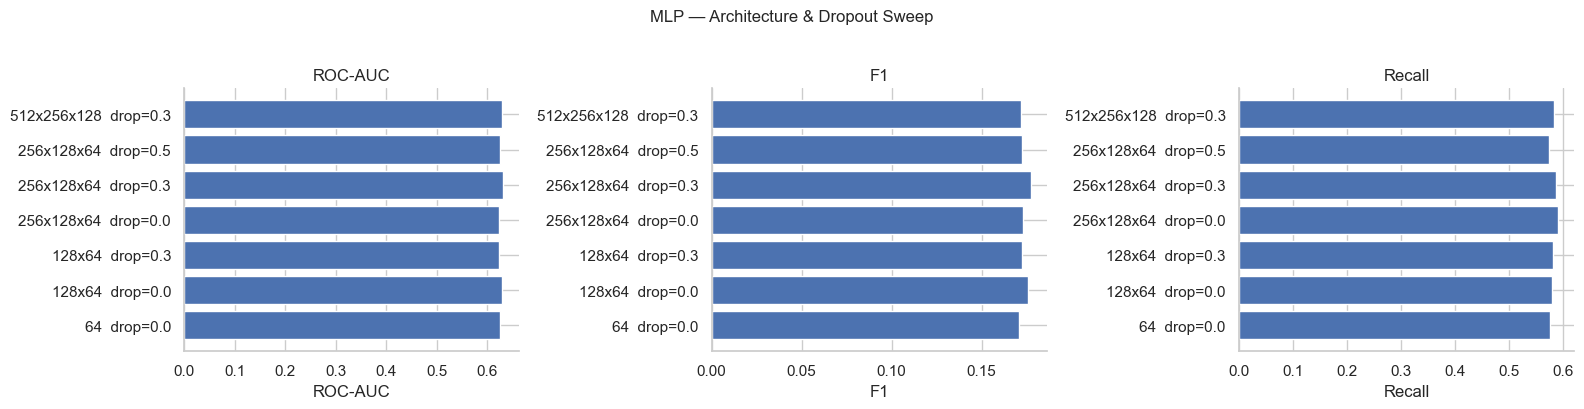

In [8]:
mlp_labels = [
    f"{'x'.join(str(h) for h in c['hidden_dims'])}  drop={c['dropout']}"
    for c in MLP_CONFIGS
]
mlp_df = results_df(mlp_grid, mlp_results, 'architecture', mlp_labels)
display(mlp_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['ROC-AUC', 'F1', 'Recall']):
    ax.barh(mlp_df.index, mlp_df[metric], color='#4C72B0')
    ax.set_title(metric)
    ax.set_xlabel(metric)
    sns.despine(ax=ax)
fig.suptitle('MLP — Architecture & Dropout Sweep', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary — Best Config per Model

In [9]:
summary = pd.concat([
    lr_df.loc[[lr_df['ROC-AUC'].idxmax()]].assign(model='LR'),
    rf_df.loc[[rf_df['ROC-AUC'].idxmax()]].assign(model='RF'),
    mlp_df.loc[[mlp_df['ROC-AUC'].idxmax()]].assign(model='MLP'),
])
display(summary[['model', 'ROC-AUC', 'F1', 'Recall', 'Precision', 'Time(s)']])

,model,ROC-AUC,F1,Recall,Precision,Time(s)
0.01,LR,0.6203,0.1703,0.5795,0.1117,14.6
10,RF,0.6296,0.1729,0.5888,0.1093,4.7
256x128x64 drop=0.3,MLP,0.6325,0.1772,0.5871,0.1164,44.4
